# Zaks et al. 2012 — strict-source MxlPy port and figure reruns

This notebook translates the public MATLAB source for the Zaks et al. qE model into a strict MxlPy-compatible wrapper, while also keeping a SciPy/BDF execution path for reproducible figure generation.

Source folders used:
- `code for the Zaks et al model`
- `Zaks et al. paper and Supplemental information`

The first pass is deliberately literal: the full RHS is ported as a coupled state-derivative model. A cleaner reaction-level refactor can be done after numeric behaviour is checked.

## Installation

Recommended environment:

```bash
uv python install 3.11
uv venv --python 3.11
source .venv/bin/activate
uv pip install mxlpy jupyter ipykernel numpy scipy pandas matplotlib
python -m ipykernel install --user --name=zaks-mxlpy --display-name "Python 3.11 (zaks-mxlpy)"
jupyter notebook
```

The notebook will read a local `params.txt` if available, otherwise it downloads it from the GitHub source URL.

In [1]:

from __future__ import annotations

import math
import re
import urllib.request
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

PARAMS_URL = "https://raw.githubusercontent.com/protonzilla/Delta_Psi_Py/master/code%20for%20the%20Zaks%20et%20al%20model%20/params.txt"
LOCAL_PARAM_CANDIDATES = [Path("params.txt"), Path("code for the Zaks et al model") / "params.txt"]

def read_params_text() -> str:
    """Read params.txt locally first; otherwise download from the canonical GitHub source."""
    for path in LOCAL_PARAM_CANDIDATES:
        if path.exists():
            return path.read_text()
    with urllib.request.urlopen(PARAMS_URL, timeout=20) as fh:
        return fh.read().decode("utf-8")

def parse_params_text(text: str) -> dict[str, float]:
    """Parse Zaks params.txt. The file is comment-heavy and not always line-oriented, so we scan name/value pairs."""
    # Remove MATLAB comments while preserving text before each %.
    clean_parts = []
    for raw_line in text.splitlines():
        clean_parts.append(raw_line.split('%', 1)[0])
    clean = "\n".join(clean_parts)

    # Robust name numeric-value scanner. Names start with a letter/underscore; values are floats/scientific notation.
    token_re = re.compile(r"\b([A-Za-z_]\w*)\s+([-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[eE][-+]?\d+)?)\b")
    params = {name: float(value) for name, value in token_re.findall(clean)}

    # Derived/convenience quantities used by the MATLAB code.
    params["voltsperlog"] = params["Rconst"] * params["Tconst"] / params["Fconst"]
    params.setdefault("PsbSDose", params.get("F_PsbS", 0.6))
    params.setdefault("F_PsbS", params.get("PsbSDose", 0.6))
    params.setdefault("fracIntactRC", 1.0)
    params.setdefault("LightIntensity", 0.0)
    return params

params = parse_params_text(read_params_text())
print(f"Loaded {len(params)} parameters")
print({k: params[k] for k in ["crosssection", "PsbSDose", "VDEpKa", "PsbSpKa", "kQ"] if k in params})


Loaded 102 parameters
{'crosssection': 0.25, 'PsbSDose': 0.6, 'VDEpKa': 6.0, 'PsbSpKa': 6.4, 'kQ': 3000000000.0}


In [2]:

# Canonical state vector assembled from initChloroplastSim.m.
STATE_NAMES = [
    "PSIIChlEx",
    "P680ex",
    "P680plus",
    "PheAnion",
    "QAox",
    "LumenProtons",
    "QBneut",
    "QBred1",
    "QBred2",
    "PQ",
    "PQH2",
    "PCr",
    "P700ox",
    "P700r",
    "Fdxr",
    "Fdxox",
    "TotalLEF",
    "ATP",
    "ActiveATPs",
    "LumenMg",
    "LumenCl",
    "LumenK",
    "Antheraxanthin",
    "Zeaxanthin",
    "PsbSQ",
]
IDX = {name: i for i, name in enumerate(STATE_NAMES)}

def initial_state(p: dict[str, float]) -> np.ndarray:
    """Initial conditions copied from initChloroplastSim.m."""
    zerolh = 1e-14
    zeroq = 1e-7

    lumen_protons_start = zerolh
    pqstart = 0.001
    qaox_start = 1 - zeroq
    pcr_start = 0.2
    atp_start = 2.0

    y0 = np.zeros(len(STATE_NAMES), dtype=float)
    values = {
        "PSIIChlEx": zerolh,
        "P680ex": zerolh,
        "P680plus": zerolh,
        "PheAnion": zerolh,
        "QAox": qaox_start,
        "LumenProtons": lumen_protons_start,
        "QBneut": 1 - 3 * zeroq,
        "QBred1": zeroq,
        "QBred2": zeroq,
        "PQ": p["QuinonePoolSize"] - 1 - pqstart,
        "PQH2": pqstart,
        "PCr": pcr_start,
        "P700ox": zerolh,
        "P700r": 1 - zerolh,
        "Fdxr": zerolh,
        "Fdxox": 1 - zerolh,
        "TotalLEF": zerolh,
        "ATP": atp_start,
        "ActiveATPs": 0.05,
        "LumenMg": p["LumenMgStart"],
        "LumenCl": p["LumenClStart"],
        "LumenK": p["LumenKStart"],
        "Antheraxanthin": zerolh,
        "Zeaxanthin": zerolh,
        "PsbSQ": zerolh,
    }
    for name, value in values.items():
        y0[IDX[name]] = value
    return y0

y0 = initial_state(params)
pd.Series(y0, index=STATE_NAMES).head(12)


PSIIChlEx       1.000000e-14
P680ex          1.000000e-14
P680plus        1.000000e-14
PheAnion        1.000000e-14
QAox            9.999999e-01
LumenProtons    1.000000e-14
QBneut          9.999997e-01
QBred1          1.000000e-07
QBred2          1.000000e-07
PQ              8.999000e+00
PQH2            1.000000e-03
PCr             2.000000e-01
dtype: float64

In [3]:

def protonation_fraction(ph: float | np.ndarray, pKa: float, hill_n: float) -> float | np.ndarray:
    """
    Hill-type protonation equilibrium used throughout the Zaks code.
    """
    return 1.0 / (1.0 + 10.0 ** (hill_n * (ph - pKa)))

def get_lumen_pH(lumen_protons: float | np.ndarray, p: dict[str, float]) -> float | np.ndarray:
    return p["pHLumenStart"] - lumen_protons / p["bufferCapacityLumen"]

def get_pH(protons: float | np.ndarray, p: dict[str, float], space: str) -> float | np.ndarray:
    if space.lower() == "lumen":
        return p["pHLumenStart"] - protons / p["bufferCapacityLumen"]
    if space.lower() == "stroma":
        return p["pHStromaStart"] - protons / p["bufferCapacityStroma"]
    raise ValueError(space)

def flux_to_concentration(flux: float | np.ndarray, space: str, p: dict[str, float]) -> float | np.ndarray:
    if space == "lumen":
        volume_correction = p["lumenVolumePerArea"]
        direction = 1.0
    elif space == "stroma":
        volume_correction = p["lumenVolumePerArea"] * p["StromaVolume"] / p["LumenVolume"]
        direction = -1.0
    else:
        raise ValueError(space)
    return direction * flux / volume_correction

def ion_flux_linear(
    lumen_conc: float | np.ndarray,
    stroma_conc: float | np.ndarray,
    delta_mu: float | np.ndarray,
    permeability: float,
    p: dict[str, float],
) -> float | np.ndarray:
    """
    Linearized ion-flux branch from evolveLumen.m.
    The MATLAB file contains a local helper with a 'lin' default.
    """
    flowout = (delta_mu > 0).astype(float) if isinstance(delta_mu, np.ndarray) else float(delta_mu > 0)
    liters_per_cc = 1e-3
    return (
        -(lumen_conc * flowout + stroma_conc * (1.0 - flowout))
        * liters_per_cc
        * permeability
        * delta_mu
        / p["voltsperlog"]
    )

def get_static_thylakoid_values(lumen: dict[str, float], stroma: dict[str, float], p: dict[str, float]) -> dict[str, float]:
    """
    Python port of getStaticThylakoidValues.m.
    """
    ph_lumen = get_pH(lumen["Protons"], p, "lumen")
    ph_stroma = get_pH(stroma["Protons"], p, "stroma")

    lumen_charge = lumen["Protons"] + p["zCl"] * lumen["Cl"] + p["zK"] * lumen["K"] + p["zMg"] * lumen["Mg"]
    stroma_charge = stroma["Protons"] + p["zCl"] * stroma["Cl"] + p["zK"] * stroma["K"] + p["zMg"] * stroma["Mg"]
    total_charge_difference = p["Fconst"] * p["lumenVolumePerArea"] * (lumen_charge - stroma_charge)

    delta_psi = total_charge_difference / p["MembraneCapacitance"]
    delta_pH = ph_stroma - ph_lumen
    pmf = delta_psi + math.log(10) * p["voltsperlog"] * delta_pH

    def delta_mu(z: float, lumen_conc: float, stroma_conc: float) -> float:
        diffusion_potential = p["voltsperlog"] * np.log(lumen_conc / stroma_conc)
        return z * delta_psi + diffusion_potential

    return {
        "pHLumen": ph_lumen,
        "pHStroma": ph_stroma,
        "deltapsi": delta_psi,
        "deltapH": delta_pH,
        "pmf": pmf,
        "deltamuCl": delta_mu(p["zCl"], lumen["Cl"], stroma["Cl"]),
        "deltamuMg": delta_mu(p["zMg"], lumen["Mg"], stroma["Mg"]),
        "deltamuK": delta_mu(p["zK"], lumen["K"], stroma["K"]),
    }

def total_q(anth: float, zea: float, psbs_q: float, p: dict[str, float], quenchmodel: int = 1) -> float:
    """
    Port of getStaticQuencherValues.m for the modes relevant to the published WT workflow.
    """
    active_psbs = psbs_q  # same overwrite used in the MATLAB file
    if quenchmodel == 0:
        q_x = 0.0
        q_l = 0.0
    elif quenchmodel == 1:
        q_x = p["zfrac"] * (zea + 0.5 * anth) * active_psbs
        q_l = (1.0 - p["zfrac"]) * active_psbs
    elif quenchmodel == 2:
        q_x = 0.0
        q_l = (1.0 - p["zfrac"]) * active_psbs
    elif quenchmodel == 3:
        q_x = p["zfrac"] * (zea + 0.5 * anth) * active_psbs
        q_l = 0.0
    elif quenchmodel == 4:
        q_x = p["zfrac"] * active_psbs
        q_l = (1.0 - p["zfrac"]) * active_psbs
    else:
        raise ValueError(f"Unsupported quenchmodel={quenchmodel}")
    return p["PsbSDose"] * (q_x + q_l)


In [9]:

def zaks_rhs(t: float, y: np.ndarray, p: dict[str, float], light_fn, quenchmodel: int = 1) -> np.ndarray:
    """
    Full-model ODE port assembled from the downloaded MATLAB module files.
    """
    (
        chl_ex,
        p680_ex,
        p680_plus,
        phe_anion,
        qa_ox,
        lumen_protons,
        qb_neut,
        qb_red1,
        qb_red2,
        pq,
        pqh2,
        pcr,
        p700_ox,
        p700_r,
        fdx_r,
        fdx_ox,
        total_lef,
        atp,
        active_atps,
        lumen_mg,
        lumen_cl,
        lumen_k,
        anth,
        zea,
        psbs_q,
    ) = y

    light = float(light_fn(t))

    lumen = {
        "Protons": lumen_protons,
        "Mg": lumen_mg,
        "Cl": lumen_cl,
        "K": lumen_k,
    }
    stroma = {
        "Protons": p["StromaProtonsStart"],
        "Mg": p["StromaMgStart"],
        "Cl": p["StromaClStart"],
        "K": p["StromaKStart"],
    }
    s = get_static_thylakoid_values(lumen, stroma, p)
    ph_lumen = s["pHLumen"]

    efield_slowdown_r = np.exp(-p["alphaRC"] * s["deltapsi"] / p["voltsperlog"])
    efield_slowdown_q = np.exp(-p["alphaQ"] * s["deltapsi"] / p["voltsperlog"])

    # -------------------------
    # F2: qE / xanthophyll cycle
    # -------------------------
    vio = p["TotalXanthophyll"] - zea - anth
    active_vde = protonation_fraction(ph_lumen, p["VDEpKa"], p["nVDE"])
    active_psbs = protonation_fraction(ph_lumen, p["PsbSpKa"], p["nPsbS"])

    r_vio_to_anth = p["VDErateVioToAnth"] * active_vde * vio
    r_anth_to_zea = p["VDErateAnthToZea"] * active_vde * anth
    r_ze = p["ZErate"] * zea
    r_ae = p["ZErate"] * anth
    r_psbs_on = p["PsbSConvertRate"] * active_psbs * (1.0 - psbs_q)
    r_psbs_off = p["PsbSConvertRate"] * (1.0 - active_psbs) * psbs_q

    d_anth = r_vio_to_anth - r_anth_to_zea + r_ze - r_ae
    d_zea = r_anth_to_zea - r_ze
    d_psbs_q = r_psbs_on - r_psbs_off

    q_total = total_q(anth, zea, psbs_q, p, quenchmodel=quenchmodel)

    # -------------------------
    # F1: PSII
    # -------------------------
    qa_red = (1.0 - qa_ox) * p["fracIntactRC"]
    p680_neut = 1.0
    phe_neut = (1.0 - phe_anion) * p["fracIntactRC"]

    rates = np.zeros(19, dtype=float)
    rates = np.maximum(rates, 0.0)
    rates[1] = light * p["crosssection"] * p["fracIntactRC"]
    rates[2] = p["kQ"] * chl_ex * q_total
    rates[3] = p["kF"] * chl_ex
    rates[4] = p["kquenchP680plus"] * chl_ex * p680_plus
    rates[5] = p["kNRantenna"] * chl_ex
    rates[7] = (p["kEETLHP680QAox"] * chl_ex * qa_ox + p["kEETLHP680QAred"] * chl_ex * qa_red) * p680_neut
    rates[8] = p["kEETLHP680revQAox"] * p680_ex * qa_ox + p["kEETLHP680revQAred"] * p680_ex * qa_red
    rates[9] = p["kNRP680"] * p680_ex
    # MATLAB creates rates(10,:) implicitly as zero because the array is preallocated.
    rates[12] = p["kETP680PheOpenRC"] * p680_ex * phe_neut * qa_ox * efield_slowdown_r
    rates[13] = p["kETP680PheClosedRC"] * p680_ex * phe_neut * qa_red * efield_slowdown_r
    rates[14] = p["kETPheToQA"] * phe_anion * qa_ox * efield_slowdown_r
    rates[15] = p["kETWaterOxidation"] * p680_plus * efield_slowdown_q
    rates[16] = p["kP680Pherecombination"] * p680_plus * phe_anion / efield_slowdown_r
    rates[17] = p["kP680QArecombination"] * p680_plus * qa_red * phe_neut / efield_slowdown_r
    rates[18] = p["kP680QArecombinationClosedRC"] * p680_plus * qa_red * phe_anion / efield_slowdown_r

    d_chl_ex = rates[1] + rates[8] - rates[2] - rates[3] - rates[4] - rates[5] - rates[7]
    d_p680_ex = rates[7] - rates[8] - rates[9] - rates[12] - rates[13]
    d_p680_plus = rates[12] + rates[13] - rates[15] - rates[16] - rates[17] - rates[18]
    d_phe_anion = rates[12] + rates[13] - rates[14] - rates[16]
    d_qa_ox_psii = -rates[14] + rates[17] + rates[18]
    d_lumen_protons_psii = rates[15] / (p["Na"] * p["LumenVolume"])

    # -------------------------
    # F3: PQ pool
    # -------------------------
    qb_empty = 1.0 - qb_neut - qb_red1 - qb_red2
    pq_frac = pq / p["QuinonePoolSize"]
    pqh2_frac = pqh2 / p["QuinonePoolSize"]

    k_qb1_to_qa = p.get("kETQB1toQA", 0.0)
    k_qb2_to_qa = p.get("kETQB2toQA", 0.0)

    r_q2 = p["kETQAtoQB1"] * qa_red * qb_neut * efield_slowdown_q
    r_q3 = p["kETQAtoQB2"] * qa_red * qb_red1 * efield_slowdown_q
    r_q4 = k_qb1_to_qa * qa_ox * qb_red1
    r_q5 = k_qb2_to_qa * qa_ox * qb_red2
    r_q6 = p["PQdockingrate"] * pq_frac * qb_empty
    r_q7 = p["PQH2undock"] * qb_red2
    r_q8 = p["PQH2undock"] * pqh2_frac / 10.0
    r_q9 = p["PQdockingrate"] * qb_neut / 10.0  # preserved even though unused in dx

    d_qa_ox_pq = r_q2 + r_q3 - r_q4 - r_q5
    d_qb_neut = r_q6 + r_q4 - r_q2
    d_qb_red1 = r_q2 + r_q5 - r_q3 - r_q4
    d_qb_red2 = r_q3 - r_q7 - r_q5 + r_q8
    d_pq = -r_q6
    d_pqh2 = r_q7 - r_q8

    # -------------------------
    # F4: cytochrome b6f
    # -------------------------
    pc_ox = p["PCperPSI"] - pcr
    fraction_active_cyt = 1.0 - protonation_fraction(ph_lumen, p["pKaC"], p["nC"])
    fraction_active_pc = pc_ox / p["PCperPSI"]
    fraction_pq_red = pqh2 / (pq + pqh2)
    fraction_activity = fraction_active_cyt * fraction_active_pc * fraction_pq_red

    r_cyt = p["QReoxidationRate"] * fraction_activity
    d_pq_cyt = r_cyt
    d_pqh2_cyt = -r_cyt
    d_pcr_cyt = (2.0 / p["ElectronsPerPC"]) * r_cyt
    d_lumen_protons_cyt = 4.0 * r_cyt / (p["Na"] * p["LumenVolume"])

    # -------------------------
    # F5: PSI
    # -------------------------

    r_psi_1 = p["kETPCP700"] * pcr * p700_ox
    r_psi_2 = light * p["PSIcrossSection"] * p["kETP700Fdx"] * p700_r * fdx_ox
    
    # MATLAB strict-port safeguard:
    r_psi_1 = max(r_psi_1, 0.0)
    r_psi_2 = max(r_psi_2, 0.0)
    
    d_pcr_psi = -r_psi_1
    d_p700_ox = -r_psi_1 + r_psi_2
    d_p700_r = r_psi_1 - r_psi_2
    d_fdx_r = r_psi_2
    d_fdx_ox = -r_psi_2
    d_total_lef = r_psi_2

    # -------------------------
    # F7: ATP synthase
    # -------------------------
    proton_flux_atp = (
        p["ATPConductivity"]
        * (s["pmf"] - p["thresholdpmf"])
        * float((s["pmf"] - p["thresholdpmf"]) > 0.0)
        * active_atps
    )
    proton_flux_leak = (
        p["leakConductivity"]
        * (s["pmf"] - p["leakpmf"])
        * float((s["pmf"] - p["leakpmf"]) > 0.0)
    )
    r_atp_activate = p["kATPsActivate"] * fdx_r * (1.0 - active_atps)
    r_atp_inactivate = p["kATPsInactivate"] * active_atps

    d_lumen_protons_atp = -flux_to_concentration(proton_flux_atp + proton_flux_leak, "lumen", p)
    vscale = p["Na"] * p["LumenVolume"] / p["lumenVolumePerArea"]
    d_atp = proton_flux_atp * (3.0 / 12.0) * vscale
    d_active_atps = r_atp_activate - r_atp_inactivate

    # -------------------------
    # F8: Lumen ion flux
    # -------------------------
    flux_mg = ion_flux_linear(lumen_mg, p["StromaMgStart"], s["deltamuMg"], p["PMg"], p)
    flux_cl = ion_flux_linear(lumen_cl, p["StromaClStart"], s["deltamuCl"], p["PCl"], p)
    flux_k = ion_flux_linear(lumen_k, p["StromaKStart"], s["deltamuK"], p["PCl"], p)  # public MATLAB uses PCl here

    d_lumen_mg = flux_to_concentration(flux_mg, "lumen", p)
    d_lumen_cl = flux_to_concentration(flux_cl, "lumen", p)
    d_lumen_k = flux_to_concentration(flux_k, "lumen", p)

    # The public evolveKea.m download is a duplicate of evolveLumen.m.
    # We keep that visible rather than silently pretending it is different.
    d_lumen_mg_total = d_lumen_mg
    d_lumen_cl_total = d_lumen_cl
    d_lumen_k_total = d_lumen_k

    return np.array(
        [
            d_chl_ex,
            d_p680_ex,
            d_p680_plus,
            d_phe_anion,
            d_qa_ox_psii + d_qa_ox_pq,
            d_lumen_protons_psii + d_lumen_protons_cyt + d_lumen_protons_atp,
            d_qb_neut,
            d_qb_red1,
            d_qb_red2,
            d_pq + d_pq_cyt,
            d_pqh2 + d_pqh2_cyt,
            d_pcr_cyt + d_pcr_psi,
            d_p700_ox,
            d_p700_r,
            d_fdx_r,
            d_fdx_ox,
            d_total_lef,
            d_atp,
            d_active_atps,
            d_lumen_mg_total,
            d_lumen_cl_total,
            d_lumen_k_total,
            d_anth,
            d_zea,
            d_psbs_q,
        ],
        dtype=float,
    )


In [10]:

# MxlPy translation layer
# ----------------------
# This is a literal mxlpy wrapping of the full Zaks RHS above. To preserve the MATLAB-like
# module coupling, each state derivative is represented as one mxlpy reaction with unit
# stoichiometry for the corresponding state. This is intentionally not yet the cleaned-up
# reaction-level model; it is the strict reproducibility port.

try:
    from mxlpy import Model, Simulator, make_protocol
    MXL_AVAILABLE = True
except Exception as exc:
    MXL_AVAILABLE = False
    print("MxlPy is not available in this environment. Install with: uv pip install mxlpy")
    print("Import error:", exc)

PARAM_NAMES = sorted(params.keys())
MXL_ARGS = ["time", *STATE_NAMES, *PARAM_NAMES]

class ZaksStateDerivative:
    """Callable rate function used by mxlpy, returning d(state)/dt from the full RHS."""
    def __init__(self, state_name: str):
        self.state_name = state_name
        self.idx = IDX[state_name]

    def __call__(self, time: float, *values: float) -> float:
        n_state = len(STATE_NAMES)
        y = np.asarray(values[:n_state], dtype=float)
        pvals = values[n_state:]
        p = dict(zip(PARAM_NAMES, pvals))
        light_value = float(p.get("LightIntensity", 0.0))
        dy = zaks_rhs(time, y, p, light_fn=lambda _t: light_value, quenchmodel=1)
        return float(dy[self.idx])


def build_zaks_mxlpy_model(parameter_values: dict[str, float] | None = None):
    if not MXL_AVAILABLE:
        raise ImportError("MxlPy is not installed. Run: uv pip install mxlpy")
    p = dict(params if parameter_values is None else parameter_values)
    p["LightIntensity"] = p.get("LightIntensity", 0.0)
    model = Model().add_parameters(p).add_variables(dict(zip(STATE_NAMES, initial_state(p))))
    for state in STATE_NAMES:
        model.add_reaction(
            f"d_{state}",
            fn=ZaksStateDerivative(state),
            args=MXL_ARGS,
            stoichiometry={state: 1.0},
        )
    return model

if MXL_AVAILABLE:
    zaks_model = build_zaks_mxlpy_model(params)
    print("MxlPy model created")
    print("States:", len(zaks_model.get_variable_names()))
    print("Derivative reactions:", len(zaks_model.get_reaction_names()))


MxlPy model created
States: 25
Derivative reactions: 25


In [11]:

# Simulation utilities and PAM-style protocols

def constant_light(light_value: float):
    return lambda t: float(light_value)


def pam_light_fn(actinic: float, pulse: float = 2000.0, measuring: float = 200.0,
                 dark_until: float = 130.0, light_until: float = 850.0,
                 pulse_start: float = 10.0, pulse_interval: float = 60.0, pulse_width: float = 0.8,
                 t_end: float = 1100.0):
    """Approximate PAM protocol: dark/measuring light, actinic light, and saturating pulses."""
    pulse_times = np.arange(pulse_start, t_end + pulse_interval, pulse_interval)
    def light(t: float) -> float:
        base = measuring if t < dark_until or t >= light_until else actinic
        for tp in pulse_times:
            if tp <= t < tp + pulse_width:
                return pulse
        return base
    return light


def simulate_zaks(p: dict[str, float], light_fn, t_span=(0.0, 1100.0), y0=None, t_eval=None,
                  quenchmodel: int = 1, method: str = "BDF", max_step: float = 1.0):
    if y0 is None:
        y0 = initial_state(p)
    sol = solve_ivp(
        fun=lambda t, y: zaks_rhs(t, y, p, light_fn=light_fn, quenchmodel=quenchmodel),
        t_span=t_span,
        y0=y0,
        t_eval=t_eval,
        method=method,
        atol=1e-8,
        rtol=1e-6,
        max_step=max_step,
    )
    if not sol.success:
        print("WARNING:", sol.message)
    return sol


def simulate_zaks_mxlpy(actinic: float, t_end: float = 1100.0, steps: int = 1101):
    """MxlPy protocol version using actinic-light steps only. Pulses are handled in the SciPy PAM helper."""
    if not MXL_AVAILABLE:
        raise ImportError("MxlPy is not installed. Run: uv pip install mxlpy")
    model = build_zaks_mxlpy_model(params)
    protocol = make_protocol([
        (130, {"LightIntensity": 200.0}),
        (720, {"LightIntensity": float(actinic)}),
        (250, {"LightIntensity": 200.0}),
    ])
    return (
        Simulator(model)
        .simulate_protocol_time_course(protocol, time_points=np.linspace(0, t_end, steps))
        .get_result()
        .unwrap_or_err()
    )


In [12]:

# Observables: fluorescence, NPQ, qE, lumen pH

def chlorophyll_observables(df: pd.DataFrame, p: dict[str, float], light_values=None, quenchmodel: int = 1) -> pd.DataFrame:
    """Port of getChlorophyllkRates.m logic for fluorescence-yield-like outputs."""
    out = pd.DataFrame(index=df.index)
    if light_values is None:
        light_values = np.zeros(len(df))
    light_values = np.asarray(light_values, dtype=float)

    kF_arr, kPC_arr, kPCRCC_arr, kC_arr, kqE_arr = [], [], [], [], []
    pHL, qtot = [], []
    for row, light in zip(df[STATE_NAMES].to_numpy(), light_values):
        (chl_ex, p680_ex, p680_plus, phe_anion, qa_ox, lumen_protons, qb_neut, qb_red1,
         qb_red2, pq, pqh2, pcr, p700_ox, p700_r, fdx_r, fdx_ox, total_lef, atp,
         active_atps, lumen_mg, lumen_cl, lumen_k, anth, zea, psbs_q) = row

        lumen = {"Protons": lumen_protons, "Mg": lumen_mg, "Cl": lumen_cl, "K": lumen_k}
        stroma = {"Protons": p["StromaProtonsStart"], "Mg": p["StromaMgStart"],
                  "Cl": p["StromaClStart"], "K": p["StromaKStart"]}
        s = get_static_thylakoid_values(lumen, stroma, p)
        pHL.append(s["pHLumen"])
        q_total = total_q(anth, zea, psbs_q, p, quenchmodel=quenchmodel)
        qtot.append(q_total)
        qa_red = (1.0 - qa_ox) * p["fracIntactRC"]
        p680_neut = 1.0
        efield_slowdown_r = np.exp(-p["alphaRC"] * s["deltapsi"] / p["voltsperlog"])

        kF = p["kF"] * chl_ex
        kqE = p["kQ"] * chl_ex * q_total
        kPC = (p["kEETLHP680QAox"] * chl_ex * qa_ox + p["kEETLHP680QAred"] * chl_ex * qa_red) * p680_neut
        kPCRCC = (p["kEETLHP680QAox"] * chl_ex * 1.0 + p["kEETLHP680QAred"] * chl_ex * 0.0) * p680_neut
        kC = p["kNRantenna"] * chl_ex + kF + p["kquenchP680plus"] * chl_ex * p680_plus
        kF_arr.append(kF); kPC_arr.append(kPC); kPCRCC_arr.append(kPCRCC); kC_arr.append(kC); kqE_arr.append(kqE)

    out["kF"] = kF_arr
    out["kPC"] = kPC_arr
    out["kPCRCC"] = kPCRCC_arr
    out["kC"] = kC_arr
    out["kqE"] = kqE_arr
    out["pHLumen"] = pHL
    out["TotalQ"] = qtot
    out["allrates"] = out["kC"] + out["kPC"] + out["kqE"]
    out["allratesRCC"] = out["kC"] + out["kPCRCC"] + out["kqE"]
    eps = np.finfo(float).tiny
    out["fluorescenceyield"] = out["kF"] / np.maximum(out["allrates"], eps)
    out["fluorescenceyieldRCC"] = out["kF"] / np.maximum(out["allratesRCC"], eps)
    out["qE_model"] = out["kqE"] / np.maximum(out["kC"], eps)
    out["phi_npq"] = out["kqE"] / np.maximum(out["allrates"], eps)
    return out


def run_pam_condition(actinic: float, qtype: int = 1, t_end: float = 1100.0, dt: float = 1.0):
    t_eval = np.arange(0.0, t_end + dt, dt)
    lf = pam_light_fn(actinic=actinic, pulse=2000.0, measuring=200.0, t_end=t_end)
    sol = simulate_zaks(params, lf, t_span=(0.0, t_end), t_eval=t_eval, quenchmodel=qtype, max_step=0.25)
    df = pd.DataFrame(sol.y.T, columns=STATE_NAMES, index=sol.t)
    light_values = np.array([lf(t) for t in sol.t])
    obs = chlorophyll_observables(df, params, light_values=light_values, quenchmodel=qtype)
    return df.join(obs), light_values


def extract_pulse_npq(out: pd.DataFrame, light_values: np.ndarray, pulse_intensity: float = 2000.0):
    pulse = light_values >= pulse_intensity
    # group consecutive pulse samples
    idx = np.where(pulse)[0]
    if len(idx) == 0:
        return pd.DataFrame(columns=["time", "Fmprime", "NPQ"])
    groups = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    times, fmps = [], []
    for g in groups:
        yy = out["fluorescenceyieldRCC"].iloc[g]
        times.append(out.index[g[0]])
        fmps.append(float(yy.max()))
    fm = fmps[0]
    return pd.DataFrame({"time": times, "Fmprime": fmps, "NPQ": [(fm - x) / x for x in fmps]})


/tmp/ipykernel_68264/3286398503.py:152: RuntimeWarning: overflow encountered in scalar multiply
  r_psi_2 = light * p["PSIcrossSection"] * p["kETP700Fdx"] * p700_r * fdx_ox
/home/yvain/github/Zaks2012/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/home/yvain/github/Zaks2012/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/home/yvain/github/Zaks2012/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/home/yvain/github/Zaks2012/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE
/tmp/ipykernel_682

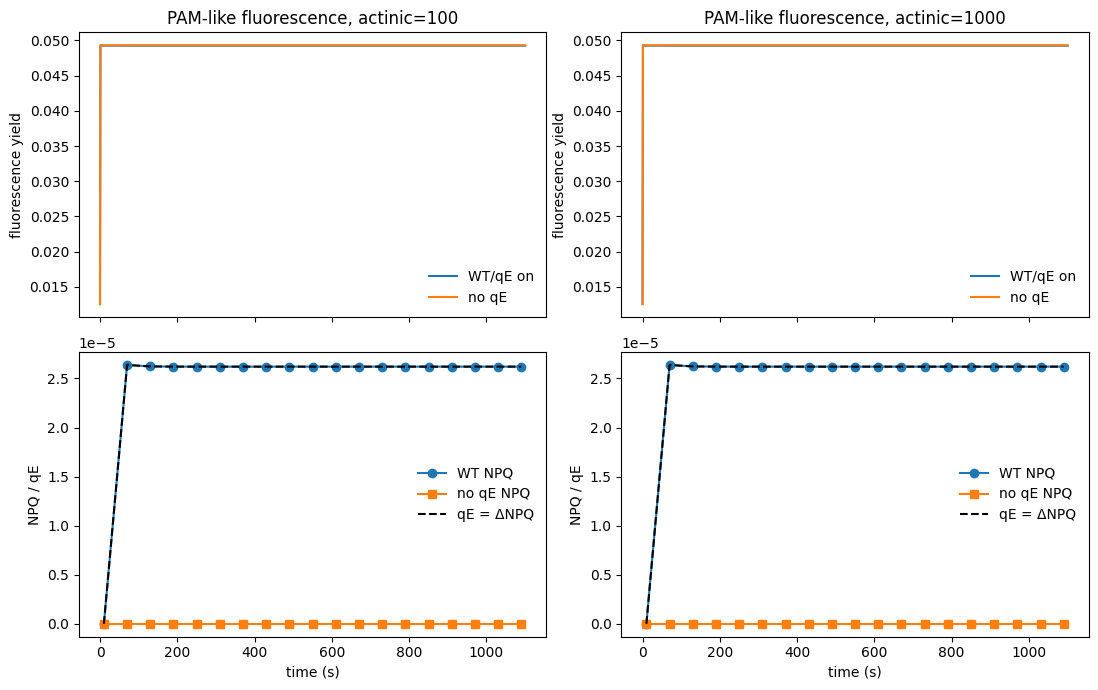

In [13]:

# Reproduce main-paper style qE / PAM simulation panels for actinic light 100 and 1000
# The paper plots measured and simulated PAM traces and qE = NPQ(WT) - NPQ(npq4).

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
summary = {}
for j, actinic in enumerate([100.0, 1000.0]):
    wt, light_wt = run_pam_condition(actinic, qtype=1)
    no_qe, light_no = run_pam_condition(actinic, qtype=0)
    wt_npq = extract_pulse_npq(wt, light_wt)
    no_npq = extract_pulse_npq(no_qe, light_no)
    qE_pulse = wt_npq["NPQ"].to_numpy() - no_npq["NPQ"].to_numpy()
    summary[actinic] = {"wt": wt, "no_qe": no_qe, "wt_npq": wt_npq, "no_npq": no_npq, "qE_pulse": qE_pulse}

    ax = axes[0, j]
    ax.plot(wt.index, wt["fluorescenceyield"], label="WT/qE on")
    ax.plot(no_qe.index, no_qe["fluorescenceyield"], label="no qE")
    ax.set_title(f"PAM-like fluorescence, actinic={actinic:g}")
    ax.set_ylabel("fluorescence yield")
    ax.legend(frameon=False)

    ax = axes[1, j]
    ax.plot(wt_npq["time"], wt_npq["NPQ"], "o-", label="WT NPQ")
    ax.plot(no_npq["time"], no_npq["NPQ"], "s-", label="no qE NPQ")
    ax.plot(wt_npq["time"], qE_pulse, "k--", label="qE = ΔNPQ")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("NPQ / qE")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()


/home/yvain/github/Zaks2012/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/home/yvain/github/Zaks2012/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/home/yvain/github/Zaks2012/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/home/yvain/github/Zaks2012/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE
/tmp/ipykernel_68264/3286398503.py:152: RuntimeWarning: overflow encountered in scalar multiply
  r_psi_2 = light * p["PSIcrossSection"] * p["kETP700Fdx"] * p700_r * fdx_ox
/home/yvain/github

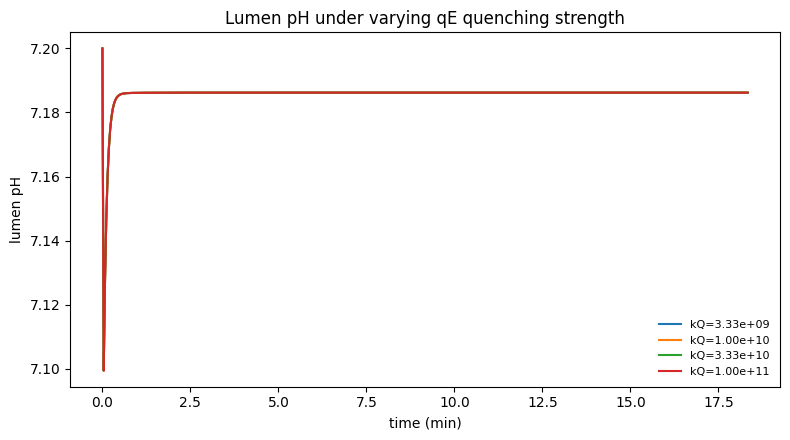

In [14]:

# Main-paper-style parameter sweep: effect of qE strength kQ on lumen pH
# This corresponds to the paper's central claim that qE changes excitation dissipation but not lumen pH strongly.

kq_values = [1/300e-12, 1/100e-12, 1/30e-12, 1/10e-12]
t_eval = np.linspace(0, 1100, 500)
fig, ax = plt.subplots(figsize=(8, 4.5))
for kq in kq_values:
    p2 = dict(params)
    p2["kQ"] = float(kq)
    lf = pam_light_fn(actinic=1000.0, pulse=2000.0, measuring=200.0, t_end=1100.0)
    sol = simulate_zaks(p2, lf, t_span=(0, 1100), t_eval=t_eval, quenchmodel=1, max_step=1.0)
    df = pd.DataFrame(sol.y.T, columns=STATE_NAMES, index=sol.t)
    obs = chlorophyll_observables(df, p2, light_values=np.array([lf(t) for t in sol.t]), quenchmodel=1)
    ax.plot(df.index / 60, obs["pHLumen"], label=f"kQ={kq:.2e}")
ax.set_xlabel("time (min)")
ax.set_ylabel("lumen pH")
ax.set_title("Lumen pH under varying qE quenching strength")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:

# Optional: save generated figures as files
# Uncomment after running the figure cells if needed.
# plt.savefig("zaks_reproduced_figure.png", dpi=300, bbox_inches="tight")


## Notes on fidelity

- This is an A-style strict reproduction port, not a cleaned-up biological model.
- The MxlPy layer wraps each state derivative as one reaction so that the original MATLAB module coupling is preserved.
- The PAM pulse helper files in the public MATLAB code are compressed/awkwardly published in the repository, so this notebook uses the agreed simplified protocol: actinic light = 100 or 1000, measuring light = 200, saturating pulses = 2000.
- After validating quantitative behaviour, the next step is to split the model into explicit module/reaction objects and remove the derivative-wrapper workaround.